<a href="https://colab.research.google.com/github/Vishalization/optimisation_resNet50/blob/main/optimization_Focal_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install disarray

In [3]:
#extract Dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/skin_split.rar"

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

!unrar x "{zip_path}" "{extract_path}"

Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025194.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025198.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025200.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025201.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025202.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025203.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025204.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025205.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025206.jpg         50%  OK 
Extracting  /content/dataset/skin_split/train/nv/ISIC_0025207.jpg         50%  OK 
Extracting  /content/dataset/

In [4]:
#Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam, AdamW, SGD

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

In [5]:
#Fix random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
#Dataset Paths
train_dir = "/content/dataset/skin_split/train"
test_dir = "/content/dataset/skin_split/test"

In [7]:
#Baseline Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [8]:
#Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 6411 images belonging to 7 classes.


In [9]:
#Val Generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1599 images belonging to 7 classes.


In [10]:
#Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [11]:
#Class Weight
class_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.3820915926179085), 1: np.float64(2.7837603126356925), 2: np.float64(1.3009334415584415), 3: np.float64(12.376447876447877), 4: np.float64(1.2863162118780096), 5: np.float64(0.2133870323525496), 6: np.float64(10.06436420722135)}


In [12]:
#Build Baseline Model
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.regularizers import l2

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tune entire network
base_model.trainable = True

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

output = Dense(
    7,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
# Custom Focal Loss

def focal_loss(gamma=2.0, alpha=0.25):

    def focal_loss_fixed(y_true, y_pred):

        epsilon = 1e-7

        y_pred = tf.clip_by_value(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        cross_entropy = -y_true * tf.math.log(y_pred)

        loss = alpha * tf.pow(
            1 - y_pred,
            gamma
        ) * cross_entropy

        return tf.reduce_mean(
            tf.reduce_sum(loss, axis=1)
        )

    return focal_loss_fixed

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),

    loss=focal_loss(
        gamma=2.0,
        alpha=0.25
    ),

    metrics=['accuracy']
)

In [15]:
#Callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_focal_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [16]:
#Train Focal Loss Model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6536 - loss: 0.6431
Epoch 1: val_accuracy improved from None to 0.67042, saving model to best_focal_model.keras

Epoch 1: finished saving model to best_focal_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 193s 621ms/step - accuracy: 0.7094 - loss: 0.5728 - val_accuracy: 0.6704 - val_loss: 0.8862 - learning_rate: 1.0000e-04
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8258 - loss: 0.4695
Epoch 2: val_accuracy did not improve from 0.67042
201/201 ━━━━━━━━━━━━━━━━━━━━ 77s 381ms/step - accuracy: 0.8203 - loss: 0.4595 - val_accuracy: 0.6704 - val_loss: 0.5751 - learning_rate: 1.0000e-04
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8819 - loss: 0.3982
Epoch 3: val_accuracy did not improve from 0.67042
201/201 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.8835 - loss: 0.3889 - val_accuracy: 0.6704 - val_loss: 1.0601 - learning_rate: 1.0000e-04
Epoch 4/15
201/201 ━━━━━━━━━━━━━━━━━━━━

In [17]:
df=pd.DataFrame(history.history)
df.to_csv('hist.csv')

<Axes: >

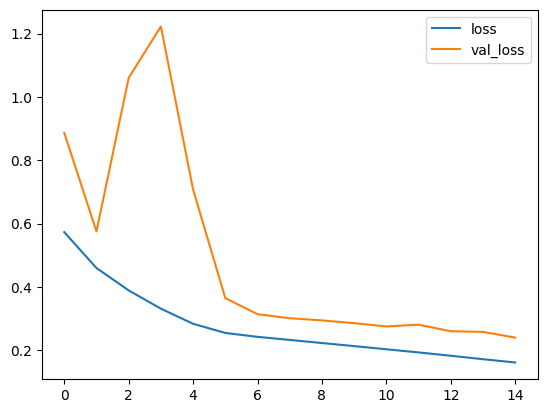

In [18]:
metrics = pd.DataFrame(history.history)
metrics[["loss","val_loss"]].plot()



<Axes: >

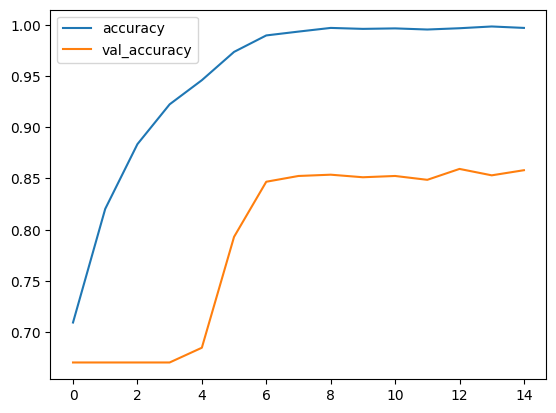

In [19]:
metrics[["accuracy","val_accuracy"]].plot()

In [20]:
model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step - accuracy: 0.8648 - loss: 0.2371


[0.2370884120464325, 0.8648378849029541]

In [21]:
predictions = model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 317ms/step


In [22]:


import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)



Normalized confusion matrix


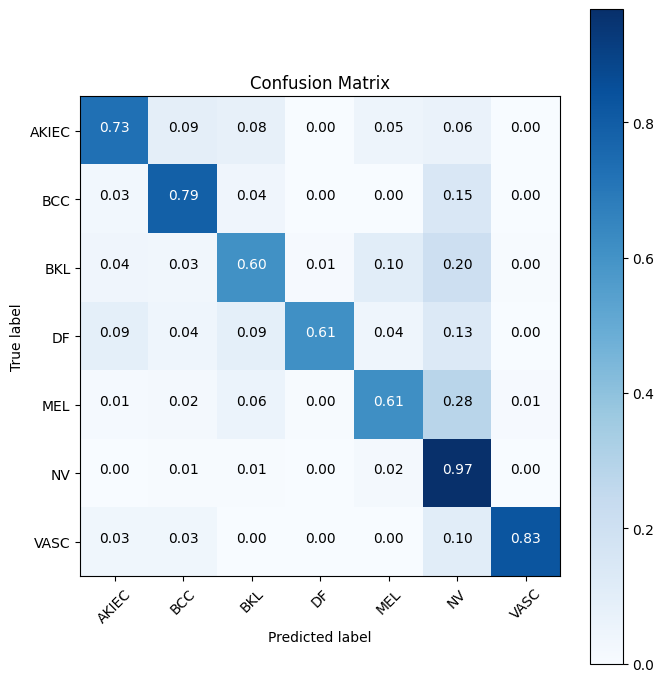

In [23]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

In [24]:
import disarray

df_cm = pd.DataFrame(
    cm,
    index=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'],
    columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
)

metrics_focal = df_cm.da.export_metrics()

metrics_focal


,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.980549,0.975561,0.941147,0.993017,0.932170,0.911721,0.995511,0.961382
f1,0.711111,0.767773,0.692708,0.666667,0.668293,0.936124,0.842105,0.864838
false_discovery_rate,0.304348,0.250000,0.189024,0.263158,0.267380,0.093007,0.142857,0.135162
false_negative_rate,0.272727,0.213592,0.395455,0.391304,0.385650,0.032811,0.172414,0.135162
false_positive_rate,0.010830,0.014196,0.017367,0.002523,0.028058,0.200301,0.002024,0.022527
negative_predictive_value,0.990702,0.988403,0.952743,0.995468,0.952695,0.923478,0.997471,0.977473
positive_predictive_value,0.695652,0.750000,0.810976,0.736842,0.732620,0.906993,0.857143,0.864838
precision,0.695652,0.750000,0.810976,0.736842,0.732620,0.906993,0.857143,0.864838
recall,0.727273,0.786408,0.604545,0.608696,0.614350,0.967189,0.827586,0.864838
sensitivity,0.727273,0.786408,0.604545,0.608696,0.614350,0.967189,0.827586,0.864838


In [ ]:
metrics_focal.to_csv("focal_loss_metrics.csv")